# Notebook: Portfolio Theory

สำหรับอ่านและทดลองคู่กับ HTML ใช้ Python 3 และ standard library กด Run All ตามลำดับได้ ภาพประกอบฝังในไฟล์นี้แล้ว ลิงก์บทเรียนชี้ไฟล์ HTML ในโฟลเดอร์ข้างเคียง ตัวเลขทุกชุดเป็นสมมติฐานเพื่อเรียนรู้ ไม่ใช่ข้อมูลตลาด

# Portfolio Theory

พอร์ตการลงทุนที่ดีเป็นอย่างไร?

> “พอร์ตที่ดีเป็นมากกว่ารายชื่อหุ้นและพันธบัตรดี ๆ ที่เรียงกันยาวเหยียด”
>
> <span lang="en">“A good portfolio is more than a long list of good stocks and bonds.”</span>
>
> — **Harry Markowitz** · [*Portfolio Selection: Efficient Diversification of Investments (1959), น. 3*](https://cowles.yale.edu/sites/default/files/2022-09/m16-all.pdf#page=15)

หลังจากที่เราหมกหมุ่นกับ ออปชั่น เรามาดูงานของ Quant ที่ไปแก้ปัญหา อีก ประเภท ในการเงินกันดีกว่า และอาจมีมูลค่าไม่ต่างกันดูซำ้ เพื่อตอบคำถามเดี่ยวว่าพอร์ตการลงทุนที่ดีคืออะไร

ทุกกการลงทุน จำเป็นต้องสร้างพอร์ตการลงทุนที่ดี (แม้คุณอาจจะไม่เคยนิยามมันก็ตาม) แต่ไม่มีศาตร์ใดพยายามหาคำตอบนี้ การวิเคราะห์ปัจจัยพื้นฐานตอบเพียงว่า มูลค่าของสินทรัพย์มันควรเป็นเท่าไหร่ การวิเคราะห์ทางเทคนิคการตอบเพียงว่าราคาหุ้นเปลี่ยนแปลงอย่างไรและมีแนวโน้มจะเป็นเช่นไร มีเพียง Quant ที่พยายามค้นหาคำตอบว่า พอร์ตการลงทุนที่ดีคืออะไร แม้คำตอบ ของ Quant สองคนอาจไม่เหมือนกัน เพื่อศึกษาสิ่งนี้เราจะพาไปรู้จักคนแรกที่ตั้งคำถามว่า
"พอร์ตการลงทุนที่ดีคืออะไร"

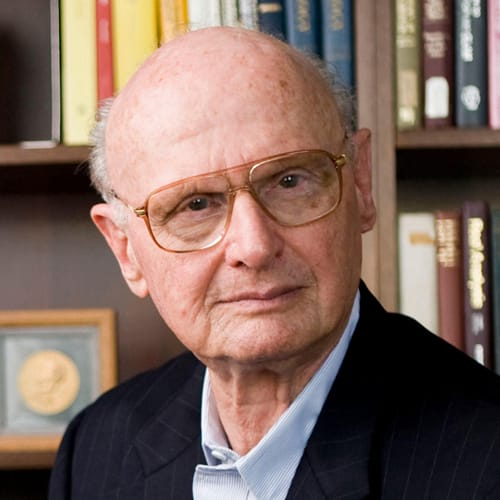

**Harry Markowitz**

ผู้วางรากฐานทฤษฎีพอร์ตการลงทุนสมัยใหม่ ซึ่งเป็นคำถามที่ตอบว่าพอร์ตการลงทุนที่ดีหน้ตาอย่างไร

ภาพและประวัติ: [Rady School of Management, UC San Diego](https://rady.ucsd.edu/faculty-research/faculty/emeriti-faculty/harry-markowitz.html)

In [1]:
import math
from fractions import Fraction
def close(actual, expected, tol=1e-10):
    assert math.isclose(actual, expected, rel_tol=tol, abs_tol=tol), (actual, expected)
MU_A, MU_B, SD_A, SD_B, RHO, RF = .12, .06, .20, .10, .20, .02
def portfolio(w, rho=RHO):
    mean = w*MU_A + (1-w)*MU_B
    variance = w*w*SD_A**2 + (1-w)**2*SD_B**2 + 2*w*(1-w)*rho*SD_A*SD_B
    sd = math.sqrt(max(0, variance))
    return mean, variance, sd
print("Hypothetical one-year simple total returns. Python standard library only.")

Hypothetical one-year simple total returns. Python standard library only.


# พอร์ตการลงทุน

เราเริ่มจากสินทรัพย์สองตัว  แล้วค่อยขยายเป็นหลายสินทรัพย์และแบบจำลองผลตอบแทน ตัวเลขทั้งหมดเป็นตัวอย่างสมมติสำหรับช่วงลงทุนหนึ่งปี

ให้ W₀ เป็นเงินลงทุนเริ่มต้น และ wᵢ เป็นสัดส่วนเงินที่ลงในสินทรัพย์ i หรือ [portfolio weight](../glossary.html#portfolio-weight) เช่น ลงเงิน 40,000 บาทจากทั้งหมด 100,000 บาท จะได้ wᵢ = 0.40

ถ้าใช้เงินทั้งหมดลงทุนในสินทรัพย์ N ตัว น้ำหนักต้องรวมกันเป็นหนึ่ง

$$
\sum_{i=1}^{N}w_i=1.
$$

เราตัดสินใจตอนเริ่มต้น แล้วถือจนครบหนึ่งปีโดยไม่ปรับสัดส่วนระหว่างทาง นี่คือแบบจำลองช่วงเวลาเดียว หรือ single-period model น้ำหนักที่กำหนดเป็นน้ำหนักเริ่มต้น ส่วนสัดส่วนมูลค่าในพอร์ตจะเปลี่ยนตามราคาที่เกิดขึ้นภายหลัง

ใช้ Rᵢ แทน [simple total return](../glossary.html#return) ของสินทรัพย์ i โดยนับเงินปันผลหรือดอกเบี้ยและการนำกลับไปลงทุนด้วย ถ้าซื้อสินทรัพย์ราคา 100 ขายเมื่อครบปีที่ 105 และรับเงินปันผล 2 ณ วันสิ้นปีพอดี ผลตอบแทนรวมคือ (105 + 2 − 100)/100 = 7%

ผลตอบแทนพอร์ต Rₚ และความมั่งคั่งปลายทาง Wₜ จึงเป็น

$$
R_P=\sum_{i=1}^{N}w_iR_i,
\qquad W_T=W_0(1+R_P).
$$

สูตรเฉลี่ยถ่วงน้ำหนักนี้ใช้กับ simple return ของช่วงเวลาเดียวกัน ส่วน [log return](../glossary.html#log-return) ของพอร์ตต้องคำนวณจาก ln(1 + Rₚ) การนำ log return ของแต่ละสินทรัพย์มาถ่วงน้ำหนักโดยตรงไม่ได้ให้ค่าเดียวกันทั่วไป

ถ้าห้าม [short selling](../glossary.html#short-selling) ให้เพิ่มเงื่อนไข wᵢ ≥ 0 เรียกว่า long-only แต่เมื่ออนุญาตให้ short น้ำหนักติดลบได้ เช่น A 120% กับ B −20% หมายถึงใช้เงินของตัวเองรวมกับเงินจากการ short B มาซื้อ A น้ำหนักสุทธิยังรวมกันได้ 100% ขณะที่มูลค่าฐานะรวมแบบไม่หักล้างกันเท่ากับ 140% ของเงินเริ่มต้น

สูตรพื้นฐานต่อไปนี้ยังไม่รวมภาษี ค่าซื้อขาย หลักประกัน และต้นทุนยืมหลักทรัพย์ สมมติว่าถือสินทรัพย์เป็นเศษส่วนได้ เราจะระบุทุกครั้งว่าสูตรเลือกน้ำหนักอนุญาตให้ short หรือจำกัดไว้ที่ long-only

## ใช้ค่าเฉลี่ยและความแปรปรวนเลือกพอร์ต

ให้ μᵢ = E[Rᵢ] เป็น [ผลตอบแทนคาดหวัง](../glossary.html#expected-value) และ σᵢ = SD(Rᵢ) เป็น [ส่วนเบี่ยงเบนมาตรฐาน](../glossary.html#standard-deviation) ของผลตอบแทน ยิ่ง σᵢ สูง ผลตอบแทนยิ่งกระจายห่างจากค่าเฉลี่ยมาก โดยนับทั้งด้านที่สูงกว่าและต่ำกว่าค่าเฉลี่ย

Mean–variance analysis เลือกพอร์ตโดยพิจารณาสองค่านี้ของพอร์ต เราอาจกำหนดเป้าผลตอบแทนคาดหวังแล้วหาพอร์ตที่มี variance ต่ำที่สุด หรือกำหนดเพดานความเสี่ยงแล้วหาพอร์ตที่มีผลตอบแทนคาดหวังสูงที่สุด

อีกวิธีคือให้ผู้ลงทุนเลือกค่าน้ำหนักลงโทษความเสี่ยง λ > 0 แล้วแก้โจทย์

$$
\max_{\mathbf w}\left(\mu_P-\frac{\lambda}{2}\sigma_P^2\right),
\qquad \sum_iw_i=1.
$$

เมื่อ λ มากขึ้น พอร์ตที่มี variance สูงจะถูกหักคะแนนมากขึ้น ตัว λ แทนความชอบในกรอบนี้ ต้องใช้หน่วยผลตอบแทนให้คงที่ และไม่ควรตีความว่าเป็นค่าบอกบุคลิกของผู้ลงทุนที่วัดได้แน่นอน

การคำนวณ μₚ กับ σₚ² ไม่ต้องสมมติว่าผลตอบแทนเป็น Normal ขอให้มีค่าเฉลี่ยและความแปรปรวนจำกัดก็พอ แต่การตัดสินใจจากสองค่านี้เพียงอย่างเดียวเป็นข้อจำกัดเพิ่มเติม พอร์ตสองชุดอาจมีค่าเฉลี่ยและ variance เท่ากัน แต่ชุดหนึ่งมีโอกาสขาดทุนรุนแรงมากกว่า

ถ้าผลตอบแทนร่วมเป็น multivariate Normal ค่าเฉลี่ยและ covariance จะกำหนดการแจกแจงร่วมได้ครบ สำหรับตระกูล elliptical ที่กว้างกว่านั้นยังต้องรู้รูปแบบการแจกแจง เช่น พารามิเตอร์หางของ t-distribution และต้องมี moment ที่ใช้คำนวณอยู่จริง การบอกเพียงว่าเป็น elliptical จึงไม่ได้ทำให้ข้อมูลเรื่องหางหายไป

## สองสินทรัพย์ที่ไม่ได้ขึ้นลงพร้อมกัน

ใช้สมมติฐานหนึ่งปีชุดนี้ตลอดตัวอย่างหลัก โดยเขียนเปอร์เซ็นต์เป็นทศนิยมเมื่อนำไปคำนวณ

| พารามิเตอร์ | สินทรัพย์ A | สินทรัพย์ B |
|---|---:|---:|
| ผลตอบแทนคาดหวัง μ | 12% | 6% |
| ส่วนเบี่ยงเบนมาตรฐาน σ | 20% | 10% |
| ความแปรปรวน σ² | 0.0400 | 0.0100 |

กำหนด correlation ของผลตอบแทน A และ B เท่ากับ ρ = 0.20 และให้อัตราปลอดความเสี่ยงหนึ่งปี r_f = 2% ไว้ใช้ภายหลัง ทั้ง μ และ σ ในตารางเป็นสถิติของผลตอบแทนหนึ่งปี ไม่ใช่ drift และ diffusion coefficient ของสมการ GBM โดยตรง

[Covariance หรือความแปรปรวนร่วม](../glossary.html#covariance) วัดว่าผลตอบแทนสองตัวเบี่ยงจากค่าเฉลี่ยไปด้วยกันอย่างไร

$$
\operatorname{Cov}(R_A,R_B)
=\mathbb E[(R_A-\mu_A)(R_B-\mu_B)]
=\rho\sigma_A\sigma_B.
$$

[Correlation](../glossary.html#correlation) คือ covariance ที่หารด้วย σ_Aσ_B จึงไม่มีหน่วยและอยู่ระหว่าง −1 กับ 1 เมื่อส่วนเบี่ยงเบนมาตรฐานทั้งคู่เป็นบวก ค่าใกล้ 1 หมายถึงเคลื่อนไหวไปด้วยกันมาก ค่าใกล้ −1 หมายถึงเคลื่อนไหวสวนกันมาก ส่วนค่า 0 หมายถึงไม่มีความสัมพันธ์เชิงเส้น ไม่ได้ยืนยันว่าเป็นอิสระจากกัน

ให้ w เป็นน้ำหนัก A และ 1 − w เป็นน้ำหนัก B จะได้

$$
\mu_P=w\mu_A+(1-w)\mu_B
$$

$$
\boxed{\sigma_P^2=w^2\sigma_A^2+(1-w)^2\sigma_B^2
+2w(1-w)\rho\sigma_A\sigma_B.}
$$

ผลตอบแทนคาดหวังเป็นค่าเฉลี่ยถ่วงน้ำหนัก แต่ variance มีพจน์ covariance เพิ่มเข้ามา เพราะเวลา A เบี่ยงจากค่าเฉลี่ย เราต้องนับด้วยว่า B มีแนวโน้มช่วยชดเชยหรือขยายการเบี่ยงนั้น

ถ้าลงทุนคนละครึ่ง ผลตอบแทนคาดหวังคือ

$$
\mu_P=0.5(0.12)+0.5(0.06)=0.09=9\%.
$$

ความแปรปรวนและส่วนเบี่ยงเบนมาตรฐานเป็น

$$
\begin{aligned}
\sigma_P^2
&=0.5^2(0.20)^2+0.5^2(0.10)^2
+2(0.5)(0.5)(0.20)(0.20)(0.10)\\
&=0.0100+0.0025+0.0020=0.0145,\\
\sigma_P&=\sqrt{0.0145}\approx0.120416=12.0416\%.
\end{aligned}
$$

การเฉลี่ย volatility ของ A กับ B ตรง ๆ จะได้ 15% ซึ่งสูงกว่า 12.0416% ของพอร์ตนี้ เมื่อสินทรัพย์ไม่ได้เคลื่อนไหวไปทางเดียวกันสมบูรณ์ การถือร่วมกันจึงลดความผันผวนจากระดับที่ได้จากการเฉลี่ย volatility เป็นผลของ [การกระจายความเสี่ยง หรือ diversification](../glossary.html#diversification)

สำหรับน้ำหนัก long-only เรามีขอบเขต

$$
|w\sigma_A-(1-w)\sigma_B|
\le\sigma_P\le w\sigma_A+(1-w)\sigma_B.
$$

ขอบบนเกิดเมื่อ ρ = 1 และขอบล่างเมื่อ ρ = −1 ถ้าสินทรัพย์ทั้งคู่มี volatility เป็นบวก น้ำหนักอยู่ระหว่าง 0 กับ 1 อย่างเคร่งครัด และ ρ < 1 ความผันผวนพอร์ตจะต่ำกว่าขอบบน สำหรับพอร์ตที่มี short ขอบบนทั่วไปต้องใช้ |w|σ_A + |1 − w|σ_B



แต่ละเส้นใช้ A และ B ชุดเดิม เปลี่ยนเฉพาะ correlation และไล่น้ำหนัก long-only ระหว่างสองสินทรัพย์ เมื่อ correlation ลดลง เส้นพอร์ตโค้งไปทางความเสี่ยงที่ต่ำลง กราฟนี้ยังไม่รวมการกู้หรือฝากที่ r_f

In [2]:
mu, variance, sd = portfolio(.5)
close(mu, .09); close(variance, .0145)
print(f"50/50: mean {100*mu:.4f}%, variance {variance:.6f}, SD {100*sd:.4f}%")
for rho in (1, .2, 0, -1):
    print(f"rho={rho:4.1f}, 50/50 SD={100*portfolio(.5,rho)[2]:.4f}%")
close(portfolio(.5, 1)[2], .15)
close(portfolio(.5, -1)[2], .05)

50/50: mean 9.0000%, variance 0.014500, SD 12.0416%
rho= 1.0, 50/50 SD=15.0000%
rho= 0.2, 50/50 SD=12.0416%
rho= 0.0, 50/50 SD=11.1803%
rho=-1.0, 50/50 SD=5.0000%


## พอร์ตที่มีความแปรปรวนต่ำที่สุด

พอร์ต [Global Minimum Variance หรือ GMV](../glossary.html#minimum-variance-portfolio) มี variance ต่ำที่สุดในบรรดาพอร์ตที่อนุญาต โดยยังไม่กำหนดผลตอบแทนเป้าหมาย สำหรับ A และ B หาได้ด้วยการดิฟเฟอเรนเชียล σₚ² ตาม w แล้วให้เท่ากับศูนย์

$$
\boxed{w_A^{\mathrm{GMV}}=
\frac{\sigma_B^2-\rho\sigma_A\sigma_B}
{\sigma_A^2+\sigma_B^2-2\rho\sigma_A\sigma_B}.}
$$

สูตรนี้อนุญาตให้ short และใช้เมื่อส่วนหารเป็นบวก ถ้ากำหนด long-only แล้วคำตอบอยู่นอกช่วง [0,1] ให้เลือกปลายช่วงที่ใกล้คำตอบนั้น สำหรับโจทย์สองสินทรัพย์นี้ variance เป็นฟังก์ชันกำลังสองนูน จึงทำเช่นนั้นได้

แทนค่าตัวอย่างจะได้

$$
w_A^{\mathrm{GMV}}=\frac{0.0100-0.0040}
{0.0400+0.0100-0.0080}=\frac17,
\qquad w_B^{\mathrm{GMV}}=\frac67.
$$

พอร์ตนี้ลงทุนใน A ประมาณ 14.2857% และ B ประมาณ 85.7143% ได้ผลตอบแทนคาดหวัง 6.8571% และส่วนเบี่ยงเบนมาตรฐาน 9.5618% จึงผันผวนต่ำกว่า B ซึ่งมี volatility 10% แม้จะมี A ที่ผันผวนกว่าปนอยู่ด้วย

คำว่า minimum variance อ้างอิงสินทรัพย์และข้อจำกัดที่เลือก พอร์ตนี้เป็น GMV ของ A กับ B หากเพิ่มสินทรัพย์ปลอดความเสี่ยงเข้ามาแล้วอนุญาตให้ถือทั้งหมด ความแปรปรวนต่ำที่สุดของชุดใหม่ย่อมเป็นศูนย์

In [3]:
cov = RHO*SD_A*SD_B
w_gmv = (SD_B**2-cov)/(SD_A**2+SD_B**2-2*cov)
close(w_gmv, 1/7)
mu_gmv, var_gmv, sd_gmv = portfolio(w_gmv)
assert all(portfolio(i/10000)[1] >= var_gmv-1e-14 for i in range(10001))
print(f"GMV: A {100*w_gmv:.6f}%, B {100*(1-w_gmv):.6f}%, mean {100*mu_gmv:.6f}%, SD {100*sd_gmv:.6f}%")

GMV: A 14.285714%, B 85.714286%, mean 6.857143%, SD 9.561829%


## พอร์ตที่คุ้มกับความเสี่ยงแต่ละระดับ

เมื่อลองน้ำหนักที่อนุญาตทั้งหมด จะได้ opportunity set หรือเซตพอร์ตที่สร้างได้ ในกราฟนี้แกนนอนเป็น σₚ และแกนตั้งเป็น μₚ เราชอบจุดที่ให้ μₚ สูงกว่าเมื่อความเสี่ยงเท่ากัน หรือมี σₚ ต่ำกว่าเมื่อผลตอบแทนคาดหวังเท่ากัน

[Efficient frontier](../glossary.html#efficient-frontier) คือกลุ่มพอร์ตที่ไม่มีพอร์ตอื่นในชุดที่อนุญาตให้ผลตอบแทนคาดหวังอย่างน้อยเท่ากันและความเสี่ยงไม่มากกว่า โดยดีกว่าอย่างเคร่งครัดอย่างน้อยหนึ่งด้าน สำหรับตัวอย่าง A กับ B แบบ long-only ส่วนที่มีประสิทธิภาพเริ่มจาก GMV แล้วเพิ่มน้ำหนัก A ไปจนถึง 100%

ช่วงจาก B ล้วนไปถึงก่อน GMV ถูกครอบงำโดย GMV เพราะ GMV ให้ทั้งผลตอบแทนคาดหวังสูงกว่าและความเสี่ยงต่ำกว่า ถ้าอนุญาตให้ short B เพื่อซื้อ A เกิน 100% เส้นพอร์ตจะต่อออกไปอีก แต่เมื่อห้าม short จุดเหล่านั้นอยู่นอกชุดทางเลือก

การเลือกจุดบน frontier ยังต้องอาศัยเป้าหมายของผู้ลงทุน คนที่รับ volatility ได้ 10% กับคนที่รับได้ 20% อาจเลือกคนละพอร์ต ทั้งสองพอร์ตอยู่บน frontier เดียวกันได้

## ผสมพอร์ตเสี่ยงกับสินทรัพย์ปลอดความเสี่ยง

สินทรัพย์ปลอดความเสี่ยงในแบบจำลองให้ผลตอบแทน r_f ที่ทราบแน่นอน ณ วันสิ้นสุดของช่วงลงทุน จึงมี variance และ covariance กับผลตอบแทนอื่นเท่ากับศูนย์ ส่วน correlation นิยามไม่ได้ เพราะสูตรต้องหารด้วย volatility ที่เป็นศูนย์

คำว่าปลอดความเสี่ยงผูกกับช่วงเวลาและหน่วยเงินที่เลือก ถ้าขายตราสารก่อนวันครบกำหนด ราคาขายอาจไม่แน่นอน และถ้าวัดด้วยสกุลเงินอื่นก็อาจมีความเสี่ยงอัตราแลกเปลี่ยน

ให้ y เป็นสัดส่วนเงินในพอร์ตเสี่ยง P และ 1 − y เป็นสัดส่วนในสินทรัพย์ปลอดความเสี่ยง ผลตอบแทนของพอร์ตผสม C คือ

$$
R_C=r_f+y(R_P-r_f),\qquad
\mu_C=r_f+y(\mu_P-r_f),\qquad
\sigma_C=|y|\sigma_P.
$$

เมื่อ 0 ≤ y ≤ 1 เราแบ่งเงินระหว่าง P กับสินทรัพย์ปลอดความเสี่ยง เมื่อ y > 1 น้ำหนักเงินสดติดลบ หมายถึงกู้เงินมาซื้อ P เพิ่ม สมการนี้สมมติว่ากู้และให้กู้ได้ที่ r_f เดียวกัน ไม่มีวงเงินหรือหลักประกันจำกัด

สำหรับ y ≥ 0 และ σₚ > 0 ตัด y ออกได้เป็นเส้นตรง

$$
\mu_C=r_f+\frac{\mu_P-r_f}{\sigma_P}\sigma_C.
$$

เส้นนี้เรียกว่า Capital Allocation Line หรือ CAL ของพอร์ต P ความชันบอกผลตอบแทนคาดหวังส่วนเกินต่อความผันผวนหนึ่งหน่วย ถ้า y < 0 เรา short พอร์ต P และต้องกลับไปใช้ σ_C = |y|σₚ การต่อสูตรเส้นด้าน y ≥ 0 ไปใช้โดยไม่เปลี่ยนเครื่องหมายจะผิด

## เลือกพอร์ตเสี่ยงที่ทำให้ CAL ชันที่สุด

[Sharpe ratio](../glossary.html#sharpe-ratio) ของพอร์ต P ในกรอบหนึ่งปีนี้คือ

$$
\operatorname{SR}_P=\frac{\mu_P-r_f}{\sigma_P},
\qquad \sigma_P>0.
$$

ถ้าต้องการผลตอบแทนคาดหวังสูงที่สุดที่ระดับ volatility หนึ่ง และสามารถผสมพอร์ตเสี่ยงกับสินทรัพย์ปลอดความเสี่ยงได้ เราจะเลือกพอร์ตที่มี Sharpe สูงที่สุดในชุดที่อนุญาต สำหรับตัวอย่างที่มี risk premium เป็นบวก เส้นจากจุด r_f จะสัมผัส frontier ที่พอร์ตนี้ จึงเรียกว่า [tangency portfolio](../glossary.html#tangency-portfolio)

พอร์ต GMV ลด variance ส่วน tangency portfolio เพิ่มอัตราส่วนผลตอบแทนส่วนเกินต่อ volatility วัตถุประสงค์ต่างกันจึงให้น้ำหนักต่างกันได้

สำหรับสองสินทรัพย์ เขียน e_A = μ_A − r_f, e_B = μ_B − r_f และ c = ρσ_Aσ_B จะได้คำตอบภายในของพอร์ต tangency

$$
w_A^T=\frac{e_A\sigma_B^2-e_Bc}
{e_A\sigma_B^2+e_B\sigma_A^2-(e_A+e_B)c},
\qquad w_B^T=1-w_A^T.
$$

สูตรนี้ใช้ในกรณีปกติที่ covariance matrix กลับด้านได้ ตัวส่วนไม่เป็นศูนย์ และพอร์ตที่ได้อยู่บนด้านผลตอบแทนส่วนเกินเป็นบวกตามข้อจำกัดที่เลือก ถ้าคำตอบละเมิด long-only ต้องแก้โจทย์ที่มีข้อจำกัดใหม่ สำหรับสองสินทรัพย์ตรวจจุดภายในกับ A ล้วนและ B ล้วนได้โดยตรง

ในตัวอย่าง e_A = 0.10, e_B = 0.04 และ c = 0.004 จึงได้

$$
w_A^T=\frac{0.10(0.01)-0.04(0.004)}
{0.10(0.01)+0.04(0.04)-0.14(0.004)}
=\frac7{17},\qquad w_B^T=\frac{10}{17}.
$$

| พอร์ต | น้ำหนัก A | μₚ | σₚ | Sharpe เมื่อ r_f = 2% |
|---|---:|---:|---:|---:|
| B ล้วน | 0% | 6.0000% | 10.0000% | 0.4000 |
| GMV | 14.2857% | 6.8571% | 9.5618% | 0.5080 |
| Tangency | 41.1765% | 8.4706% | 11.0363% | 0.5863 |
| คนละครึ่ง | 50% | 9.0000% | 12.0416% | 0.5813 |
| A ล้วน | 100% | 12.0000% | 20.0000% | 0.5000 |

พอร์ตคนละครึ่งมี μₚ สูงกว่า tangency แต่เมื่อหารผลตอบแทนส่วนเกินด้วย volatility แล้วได้ Sharpe ต่ำกว่าเล็กน้อย หากต้องการความเสี่ยงมากขึ้น เราสามารถเพิ่ม y ในพอร์ต tangency แทนการเปลี่ยนสัดส่วน A กับ B



GMV อยู่ซ้ายสุดของชุดพอร์ต A กับ B ส่วน tangency อยู่ตรงจุดที่เส้น CAL ให้ Sharpe สูงที่สุดสำหรับพารามิเตอร์นี้ การเพิ่มน้ำหนักพอร์ต tangency เกิน 100% ต้องกู้เงินที่ 2% ตามสมมติฐาน

ถ้าลงทุน 50% ใน tangency และ 50% ในสินทรัพย์ปลอดความเสี่ยง จะได้ μ_C ≈ 5.2353% และ σ_C ≈ 5.5181% ถ้าลงทุนใน tangency 150% โดยกู้ 50% ของเงินเริ่มต้น จะได้ μ_C ≈ 11.7059% และ σ_C ≈ 16.5544% ทั้งสองพอร์ตมี Sharpe เดียวกันภายใต้ต้นทุนเงินที่กำหนด

**ถ้ามีค่า λ แล้วควรแบ่งเงินเข้าพอร์ต tangency เท่าไร**

นำ μ_C = r_f + y(μ_T − r_f) และ σ_C² = y²σ_T² ไปแทนในเป้าหมาย mean–variance แล้วดิฟเฟอเรนเชียลตาม y จะได้

$$
y^*=\frac{\mu_T-r_f}{\lambda\sigma_T^2}.
$$

ถ้า λ = 4 และใช้ผลตอบแทนเป็นทศนิยม ตัวอย่างให้ y* = 1.328125 หรือประมาณ 132.81% ใน tangency จึงมีเงินกู้ประมาณ 32.81% หากข้อจำกัดห้ามกู้และห้าม short พอร์ตเสี่ยง ต้องบังคับ 0 ≤ y ≤ 1 และคำตอบของโจทย์นี้จะอยู่ที่ y = 1

### เมื่อ correlation เท่ากับ −1

เมื่อ A กับ B สวนทางกันสมบูรณ์ เลือก w_A = σ_B/(σ_A + σ_B) = 1/3 และ w_B = 2/3 แล้วได้ σₚ = 0 ผลตอบแทนจึงเท่ากับค่าเฉลี่ยของมันเกือบแน่นอน ซึ่งในตัวอย่างเท่ากับ 8%

แต่เรากำหนด r_f = 2% ไว้ด้วย หากกู้ที่ 2% มาลงในพอร์ตที่จ่ายแน่นอน 8% ได้โดยไม่มีข้อจำกัด จะเกิด [arbitrage](../glossary.html#arbitrage) ตัวเลขที่ตั้งไว้จึงไม่สอดคล้องกับตลาดที่ไม่มี arbitrage เมื่อ ρ = −1 พอดี

การเลื่อน correlation ไปถึง −1 ช่วยตรวจพฤติกรรมของสูตรความเสี่ยง ส่วนการใช้ชุดค่านั้นเป็นแบบจำลองตลาดต้องตรวจผลตอบแทนของพอร์ตศูนย์ความเสี่ยงกับ r_f ด้วย Sharpe ที่หารด้วยศูนย์ไม่ใช่คะแนนพอร์ตที่ใช้จัดอันดับได้

In [4]:
# Solve the two-by-two system Sigma z = mu - rf*1.
cov = RHO*SD_A*SD_B
det = SD_A**2*SD_B**2-cov**2
z_a = (SD_B**2*(MU_A-RF)-cov*(MU_B-RF))/det
z_b = (SD_A**2*(MU_B-RF)-cov*(MU_A-RF))/det
w_t = z_a/(z_a+z_b)
mu_t, var_t, sd_t = portfolio(w_t)
sharpe = (mu_t-RF)/sd_t
close(w_t, 7/17); close(var_t, 88/7225)
assert all((portfolio(i/10000)[0]-RF)/portfolio(i/10000)[2] <= sharpe+1e-12 for i in range(10001))
print(f"Tangency: A {100*w_t:.6f}%, mean {100*mu_t:.6f}%, SD {100*sd_t:.6f}%, Sharpe {sharpe:.6f}")
for y in (.5, 1, 1.5):
    print(f"Risky weight={y:.1f}, risk-free weight={1-y:.1f}: mean={100*(RF+y*(mu_t-RF)):.4f}%, SD={100*abs(y)*sd_t:.4f}%")
zero_mean, zero_var, zero_sd = portfolio(1/3, -1)
close(zero_var, 0); close(zero_mean, .08)
print(f"rho=-1: zero-variance return={100*zero_mean:.1f}%; spread above rf={100*(zero_mean-RF):.1f} percentage points. Inconsistent with frictionless no-arbitrage.")

Tangency: A 41.176471%, mean 8.470588%, SD 11.036272%, Sharpe 0.586302
Risky weight=0.5, risk-free weight=0.5: mean=5.2353%, SD=5.5181%
Risky weight=1.0, risk-free weight=0.0: mean=8.4706%, SD=11.0363%
Risky weight=1.5, risk-free weight=-0.5: mean=11.7059%, SD=16.5544%
rho=-1: zero-variance return=8.0%; spread above rf=6.0 percentage points. Inconsistent with frictionless no-arbitrage.


## ขยายเป็น N สินทรัพย์ด้วยเมทริกซ์

ให้ **w** เป็นเวกเตอร์คอลัมน์ของน้ำหนัก **μ** เป็นเวกเตอร์ผลตอบแทนคาดหวัง และ Σ เป็น covariance matrix ซึ่งมีสมาชิก Σᵢⱼ = Cov(Rᵢ,Rⱼ) แนวทแยงเป็น variance ของแต่ละสินทรัพย์ ส่วนสมาชิกนอกแนวทแยงเป็น covariance ของแต่ละคู่

$$
\mathbf w=\begin{pmatrix}w_1\\ \vdots\\ w_N\end{pmatrix},
\quad \boldsymbol\mu=\begin{pmatrix}\mu_1\\ \vdots\\ \mu_N\end{pmatrix},
\quad \mu_P=\mathbf w^\top\boldsymbol\mu,
\quad \sigma_P^2=\mathbf w^\top\Sigma\mathbf w.
$$

เครื่องหมาย ᵀ หรือ ⊤ คือ transpose เปลี่ยนเวกเตอร์คอลัมน์เป็นแถว ให้ **1** เป็นเวกเตอร์ที่ทุกช่องเท่ากับหนึ่ง เงื่อนไขใช้งบทั้งหมดจึงเขียนสั้น ๆ ว่า **1**ᵀ**w** = 1

สำหรับ A กับ B covariance matrix คือ

$$
\Sigma=\begin{pmatrix}0.0400&0.0040\\0.0040&0.0100\end{pmatrix}.
$$

ถ้าต้องการผลตอบแทนคาดหวังเป้าหมาย m ปัญหาเลือกพอร์ตเขียนได้เป็น

$$
\min_{\mathbf w}\ \mathbf w^\top\Sigma\mathbf w,
\qquad \mathbf1^\top\mathbf w=1,
\qquad \boldsymbol\mu^\top\mathbf w=m.
$$

เงื่อนไข long-only เพิ่มได้ด้วย wᵢ ≥ 0 และอาจเพิ่มเพดานน้ำหนักรายสินทรัพย์ ผลตอบแทนเป้าหมายบางค่าอาจทำไม่ได้ภายใต้ข้อจำกัดเหล่านั้น เช่น ในตัวอย่าง long-only ของ A กับ B ค่า m ต้องอยู่ระหว่าง 6% กับ 12%

เมื่อ Σ เป็น positive definite จึงกลับด้านได้ และอนุญาตให้ short สูตร GMV เป็น

$$
\mathbf w_G=
\frac{\Sigma^{-1}\mathbf1}{\mathbf1^\top\Sigma^{-1}\mathbf1}.
$$

ส่วนพอร์ต tangency ในกรณีปกติที่ผลรวมด้านล่างเป็นบวก คือ

$$
\mathbf w_T=
\frac{\Sigma^{-1}(\boldsymbol\mu-r_f\mathbf1)}
{\mathbf1^\top\Sigma^{-1}(\boldsymbol\mu-r_f\mathbf1)}.
$$

ตัวเศษให้น้ำหนักที่คำนึงถึงทั้งผลตอบแทนส่วนเกินและ covariance ส่วนตัวหารปรับให้น้ำหนักรวมเป็นหนึ่ง ถ้า Σ เป็น singular เช่น มีสินทรัพย์ซ้ำกันสมบูรณ์ สูตร inverse นี้ใช้ไม่ได้ ต้องแก้โครงสร้างสินทรัพย์หรือใช้วิธีที่จัดการเมทริกซ์เอกฐานโดยตรง

ในโค้ดจริงสามารถแก้ระบบสมการ Σx = **1** หรือ Σx = **μ** − r_f**1** แทนการคำนวณ inverse ทั้งก้อน แล้วจึง normalize x การคำนวณยังต้องตรวจข้อจำกัดน้ำหนักและความสมเหตุสมผลของผลลัพธ์

**สูตร frontier เมื่ออนุญาตให้ short**

กำหนด a = **1**ᵀΣ⁻¹**1**, b = **1**ᵀΣ⁻¹**μ**, c = **μ**ᵀΣ⁻¹**μ** และ d = ac − b² ถ้า Σ เป็น positive definite และผลตอบแทนคาดหวังไม่ได้เท่ากันทุกสินทรัพย์ จะได้ d > 0 พอร์ต variance ต่ำที่สุดที่เป้าหมาย m มีน้ำหนัก

$$
\mathbf w(m)=\Sigma^{-1}\left[
\frac{c-bm}{d}\mathbf1+\frac{am-b}{d}\boldsymbol\mu
\right]
$$

และ variance เป็น

$$
\sigma^2(m)=\frac{am^2-2bm+c}{d}.
$$

GMV อยู่ที่ m = b/a และมี variance 1/a ส่วน efficient frontier เป็นด้าน m ≥ b/a สูตรนี้ยังไม่ได้บังคับน้ำหนักไม่ติดลบ เมื่อต้องการ long-only ต้องแก้โจทย์ที่เพิ่มข้อจำกัดนั้น

## เพิ่มจำนวนสินทรัพย์แล้วความเสี่ยงเหลืออะไร

ลองสร้างตลาดสมมติที่สินทรัพย์ทุกตัวมีผลตอบแทนคาดหวัง μ เท่ากัน มี volatility σ เท่ากัน และมี correlation ระหว่างคู่ที่ต่างกันเท่ากับ ρ จากนั้นลงทุนเท่ากัน N ตัว ตัวละ 1/N

ผลตอบแทนคาดหวังของพอร์ตยังเท่ากับ μ ส่วน variance แยกเป็นพจน์ของสินทรัพย์แต่ละตัว N พจน์ และพจน์ covariance ของคู่ที่ต่างกัน N(N − 1) พจน์

$$
\begin{aligned}
\sigma_P^2
&=\frac{N\sigma^2+N(N-1)\rho\sigma^2}{N^2}\\
&=\sigma^2\left[\rho+\frac{1-\rho}{N}\right].
\end{aligned}
$$

ถ้า ρ = 0 จะได้ σₚ = σ/√N การลด volatility ลงครึ่งหนึ่งจึงต้องเพิ่มจำนวนสินทรัพย์เป็นสี่เท่าในแบบจำลองนี้ แต่ถ้า ρ > 0 คงที่ จะได้

$$
\lim_{N\to\infty}\sigma_P^2=\rho\sigma^2,
\qquad \lim_{N\to\infty}\sigma_P=\sigma\sqrt\rho.
$$

ใช้ σ = 20% และ ρ = 0.20 เมื่อถือ 5 ตัว volatility พอร์ตเป็น 12% เมื่อถือ 25 ตัวเป็นประมาณ 9.6333% และเมื่อถือ 100 ตัวเป็นประมาณ 9.1214% ขอบล่างเมื่อ N เพิ่มไม่จำกัดคือประมาณ 8.9443%



กราฟใช้สินทรัพย์สมมติที่มี volatility 20% เท่ากันทุกตัว เส้นที่มี correlation เป็นบวกเข้าใกล้ขอบล่าง σ√ρ ผลขึ้นอยู่กับสมมติฐานนี้ จึงไม่มีจำนวนสินทรัพย์ตายตัวที่รับประกันว่ากระจายความเสี่ยงพอแล้ว

ความสัมพันธ์ร่วมกันทำให้ความเสี่ยงส่วนหนึ่งยังเหลือ แม้เพิ่มชื่อสินทรัพย์ไปเรื่อย ๆ การเพิ่มสินทรัพย์ที่มีความเสี่ยงคนละแบบอาจช่วยได้มากกว่าการเพิ่มสินทรัพย์ที่ตอบสนองต่อปัจจัยเดิม แต่ต้องประมาณ covariance ใหม่ให้ตรงกับชุดสินทรัพย์นั้น

### Correlation ติดลบมีข้อจำกัดเมื่อ N เพิ่ม

ค่า correlation รายคู่ที่ดูเป็นไปได้อาจรวมกันเป็นเมทริกซ์ที่เป็นไปไม่ได้ Covariance matrix ต้องเป็น positive semidefinite หมายความว่า **w**ᵀΣ**w** ≥ 0 สำหรับทุก **w** เพราะ variance ติดลบไม่ได้

สำหรับ N ≥ 2 ที่ใช้ correlation เท่ากันทุกคู่ ต้องมี

$$
-\frac1{N-1}\le\rho\le1.
$$

เช่น ρ = −0.20 ใช้ได้มากที่สุด N = 6 ในโครงสร้างนี้ การคง ρ = −0.20 แล้วเพิ่ม N ไปถึง 100 จะสร้าง covariance matrix ที่ไม่ถูกต้อง จึงใช้สูตรแล้วตีความ variance ติดลบว่าเป็นความเสี่ยงต่ำมากไม่ได้ ที่ N = 6 และ ρ = −0.20 พอร์ตน้ำหนักเท่ากันมี variance ศูนย์ ต้องตรวจความสอดคล้องกับ r_f ถ้าเพิ่มสินทรัพย์ปลอดความเสี่ยงเข้ามาด้วย

In [5]:
for n in (1, 5, 10, 50, 100):
    sd = .2*math.sqrt(.2+.8/n)
    independent_sd = .2/math.sqrt(n)
    print(f"N={n:3}: SD with rho=.2: {100*sd:.4f}%; rho=0: {100*independent_sd:.4f}%")
print(f"Limit for rho=.2: {100*.2*math.sqrt(.2):.4f}%")
close(.2**2*(.2+.8/50), .00864)
assert -.1 < -1/(50-1)  # Invalid constant pairwise correlation for 50 assets.

N=  1: SD with rho=.2: 20.0000%; rho=0: 20.0000%
N=  5: SD with rho=.2: 12.0000%; rho=0: 8.9443%
N= 10: SD with rho=.2: 10.5830%; rho=0: 6.3246%
N= 50: SD with rho=.2: 9.2952%; rho=0: 2.8284%
N=100: SD with rho=.2: 9.1214%; rho=0: 2.0000%
Limit for rho=.2: 8.9443%


## จากพอร์ตที่แต่ละคนเลือก สู่ CAPM

จนถึงตอนนี้ μ และ Σ เป็นข้อมูลที่ผู้ลงทุนคนหนึ่งใช้เลือกพอร์ต หากผู้ลงทุนประมาณค่าต่างกัน พอร์ต tangency ที่เลือกก็ต่างกันได้

[CAPM](../glossary.html#capm) เพิ่มเงื่อนไขระดับตลาด ผู้ลงทุนพิจารณาช่วงเวลาเดียวกัน ใช้ชุดสินทรัพย์เดียวกัน มีประมาณการค่าเฉลี่ยและ covariance เหมือนกัน ตัดสินใจด้วย mean–variance และกู้หรือให้กู้ที่อัตราปลอดความเสี่ยงเดียวกันในตลาดไร้ต้นทุนซื้อขาย ภายใต้เงื่อนไขมาตรฐานที่ให้พอร์ต tangency เดียวกัน ทุกคนจึงถือส่วนเสี่ยงในสัดส่วนเดียวกันแล้วเลือก y ตามความต้องการของตัวเอง

เมื่อรวมการถือของทุกคนและให้ตลาดเข้าสู่ดุลยภาพ ความต้องการสินทรัพย์ต้องตรงกับจำนวนที่มีอยู่ พอร์ต tangency ร่วมจึงเป็น market portfolio หรือพอร์ตสินทรัพย์เสี่ยงทั้งหมดถ่วงน้ำหนักตามมูลค่าตลาด เส้น CAL ของพอร์ตตลาดเรียกว่า Capital Market Line หรือ CML

$$
\mu_C=r_f+\frac{\mu_M-r_f}{\sigma_M}\sigma_C.
$$

M แทนพอร์ตตลาด และ C แทนพอร์ตที่ผสม M กับสินทรัพย์ปลอดความเสี่ยงโดยถือน้ำหนัก M ไม่ติดลบ CML จึงอธิบายพอร์ตที่มีประสิทธิภาพกลุ่มนี้ ไม่ใช่เส้นที่สินทรัพย์รายตัวทุกตัวต้องอยู่บนเส้น

สำหรับสินทรัพย์หรือพอร์ต i CAPM เชื่อมผลตอบแทนคาดหวังกับความเสี่ยงที่มีร่วมกับตลาดผ่าน [beta](../glossary.html#portfolio-beta)

$$
\beta_i=\frac{\operatorname{Cov}(R_i,R_M)}
{\operatorname{Var}(R_M)},\qquad \operatorname{Var}(R_M)>0,
$$

$$
\boxed{\mathbb E[R_i]-r_f=\beta_i(\mathbb E[R_M]-r_f).}
$$

Beta วัดการตอบสนองเชิงเส้นต่อผลตอบแทนตลาด ถ้า beta = 1.2 การเปลี่ยนผลตอบแทนตลาดหนึ่ง percentage point สัมพันธ์กับการเปลี่ยนผลตอบแทนของสินทรัพย์ประมาณ 1.2 percentage points ในส่วนที่อธิบายด้วยตลาด โดยยังมีความเคลื่อนไหวเฉพาะตัวเหลือได้

เมื่อพล็อตสมการ CAPM โดยใช้ beta เป็นแกนนอนและ μ เป็นแกนตั้ง จะได้ Security Market Line หรือ SML ตัวอย่างสมมติแยกจาก A กับ B ให้ r_f = 2% และ μ_M = 8% สินทรัพย์ที่ beta = 1.2 มีผลตอบแทนคาดหวังตาม CAPM เท่ากับ 2% + 1.2(8% − 2%) = 9.2%



SML ใช้ beta บนแกนนอน ต่างจาก CAL และ CML ที่ใช้ volatility จุด beta = 1.2 จึงให้ μ = 9.2% ในตัวอย่าง CAPM นี้

| เส้น | แกนนอน | ใช้กับอะไร |
|---|---|---|
| CAL | Volatility σ | พอร์ตเสี่ยงหนึ่งชุดผสมกับสินทรัพย์ปลอดความเสี่ยง |
| CML | Volatility σ | พอร์ตตลาดผสมกับสินทรัพย์ปลอดความเสี่ยง ภายใต้ดุลยภาพ CAPM |
| SML | Beta β | ผลตอบแทนคาดหวังของสินทรัพย์และพอร์ตตาม CAPM |

CAPM ให้ค่าคาดหมายภายใต้สมมติฐานของแบบจำลอง สินทรัพย์ beta สูงยังให้ผลตอบแทนต่ำหรือติดลบในปีใดปีหนึ่งได้ ส่วน beta ต่ำก็อยู่ร่วมกับ volatility สูงได้ หากสินทรัพย์นั้นมีความเสี่ยงเฉพาะตัวสูง

พอร์ตตลาดในทฤษฎีกว้างกว่าดัชนีหุ้นหนึ่งดัชนี เมื่อนำดัชนีมาใช้แทน จะได้ beta และผลทดสอบที่ขึ้นกับตัวแทนตลาดนั้นด้วย

In [6]:
market_mean, beta = .08, 1.2
capm_mean = RF+beta*(market_mean-RF)
close(capm_mean, .092)
print(f"CAPM expected return with beta 1.2 = {100*capm_mean:.2f}%")
market_sd, residual_sd = .15, .10
total_variance = beta**2*market_sd**2 + residual_sd**2
print(f"Single-factor total SD: {100*math.sqrt(total_variance):.4f}%")
print(f"100 equal-weight assets with independent same-size residuals: {100*math.sqrt(beta**2*market_sd**2+residual_sd**2/100):.4f}%")

CAPM expected return with beta 1.2 = 9.20%
Single-factor total SD: 20.5913%
100 equal-weight assets with independent same-size residuals: 18.0278%


## แยกความเสี่ยงด้วย factor model

[Factor model](../glossary.html#factor-model) แบบหนึ่งปัจจัยที่ใช้ตลาดเป็น factor เขียนในรูป excess return ได้ว่า

$$
R_i-r_f=\alpha_i+\beta_i(R_M-r_f)+\varepsilon_i.
$$

αᵢ เป็น intercept หรือค่าคงที่ βᵢ เป็นความไวต่อ factor และ εᵢ เป็น residual ที่เหลือจากสมการ สมมติ E[εᵢ] = 0 และ Cov(εᵢ,R_M) = 0 จะได้

$$
\mathbb E[R_i]-r_f=\alpha_i+\beta_i(\mu_M-r_f),
\qquad \sigma_i^2=\beta_i^2\sigma_M^2+\sigma_{\varepsilon_i}^2.
$$

ส่วนแรกของ variance มาจากความเสี่ยงร่วมกับตลาด ส่วนหลังเป็นความเสี่ยงเฉพาะตัวที่แบบจำลองนี้ยังอธิบายไม่ได้ การแยก variance แบบนี้อาศัย covariance ระหว่าง factor กับ residual เป็นศูนย์ ไม่จำเป็นต้องให้ residual เป็น Normal

ถ้าสมมติเพิ่มว่า residual ของคนละสินทรัพย์ไม่มี covariance กัน จะได้สำหรับ i ≠ j

$$
\operatorname{Cov}(R_i,R_j)=\beta_i\beta_j\sigma_M^2.
$$

พอร์ตจึงมี βₚ = Σᵢwᵢβᵢ และ variance

$$
\sigma_P^2=\beta_P^2\sigma_M^2+
\sum_iw_i^2\sigma_{\varepsilon_i}^2.
$$

ถ้าถือ N ตัวเท่ากัน ทุกตัวมี beta = β และ residual variance = s² ส่วนเฉพาะตัวเหลือ s²/N ขณะที่ส่วนตลาดยังเป็น β²σ_M² การเพิ่มจำนวนสินทรัพย์จึงลดความเสี่ยงเฉพาะตัวได้ภายใต้โครงสร้างนี้ ถ้า residual ยังสัมพันธ์กัน ต้องนับ covariance ที่เหลือด้วย

สมการ regression บอกความสัมพันธ์เชิงสถิติในข้อมูล ส่วน CAPM เพิ่มข้อจำกัดเชิงเศรษฐศาสตร์ว่า expected excess return ควรเป็น βᵢ(μ_M − r_f) หรือ αᵢ = 0 ในรูป excess-return นี้ การรัน regression ได้ beta จึงยังไม่ได้พิสูจน์ CAPM และค่า alpha ที่ประมาณได้ไม่เป็นศูนย์อาจมาจากความคลาดเคลื่อนในการประมาณหรือ factor ที่ขาดไป

### หลายปัจจัยและ APT

ถ้ามีปัจจัยร่วม K ตัว ขยายแบบจำลองเป็น

$$
R_i-r_f=\alpha_i+\sum_{k=1}^{K}\beta_{ik}F_k+\varepsilon_i.
$$

F_k เป็นค่าของ factor ในช่วงเวลานั้น ส่วน βᵢₖ เป็นความไวของสินทรัพย์ i ต่อ factor k ต้องระบุหน่วยและนิยามของ F_k ก่อน เช่น ผลตอบแทนของพอร์ต long–short หรือการเปลี่ยนแปลงของตัวแปรเศรษฐกิจที่ปรับค่าเฉลี่ยแล้ว สองแบบนี้มีความหมายของ intercept และค่าคาดหมายต่างกัน

ถ้าเขียน β ทั้งหมดเป็นเมทริกซ์ B, covariance ของ factors เป็น Ω และ covariance ของ residuals เป็น D โดย factors ไม่มี covariance กับ residuals จะได้

$$
\Sigma=B\Omega B^\top+D.
$$

การกำหนด D เป็นเมทริกซ์แนวทแยงช่วยลดจำนวนพารามิเตอร์ แต่ต้องยอมรับสมมติฐานว่า residual ข้ามสินทรัพย์ไม่สัมพันธ์กัน การใส่ factor เพิ่มสามารถอธิบายข้อมูลในตัวอย่างได้ดีขึ้น จึงต้องทดสอบกับข้อมูลที่ไม่ได้ใช้เลือก factor ด้วย

Arbitrage Pricing Theory หรือ APT ใช้โครงสร้างหลายปัจจัยร่วมกับเงื่อนไขไม่มี arbitrage และการกระจายความเสี่ยงเฉพาะตัว เพื่อให้ได้ความสัมพันธ์ของผลตอบแทนคาดหวังในรูป

$$
\mathbb E[R_i]-r_f=\sum_{k=1}^{K}\beta_{ik}\lambda_k.
$$

λ_k คือ risk premium ต่อความไวหนึ่งหน่วยของ factor k ผลแบบ exact ต้องมีเงื่อนไขรองรับ เช่น ปัจจัยอธิบายความเสี่ยงได้ครบ ส่วนกรอบสินทรัพย์จำนวนมากที่ยังมี residual ให้ความสัมพันธ์โดยประมาณภายใต้เงื่อนไขการกระจายความเสี่ยง APT ไม่ได้กำหนดเองว่าควรเลือก factor ตัวใด และไม่ต้องตั้งต้นว่าทุกคนถือ market portfolio เดียวกันแบบ CAPM

ถ้า factor เป็นผลตอบแทนส่วนเกินของพอร์ตที่ซื้อขายได้และ normalize exposure เหมาะสม λ_k อาจตีความเป็นค่าคาดหมายของผลตอบแทน factor นั้นได้ แต่เมื่อ F_k เป็นช็อกเศรษฐกิจที่มีค่าเฉลี่ยศูนย์ λ_k ยังเป็นราคาของความเสี่ยง จึงไม่ควรแทนด้วย E[F_k] = 0

เอกสารต้นทางยกแบบจำลองเชิงประจักษ์ เช่น Fama–French ที่ใช้ market, size และ value; Carhart ที่เพิ่ม momentum; และ Pástor–Stambaugh ที่พิจารณาความเสี่ยงสภาพคล่อง ชื่อ factor บอกโครงสร้างที่ต้องกำหนดและทดสอบเพิ่มเติม ไม่ได้รับประกันผลตอบแทนบวกในทุกช่วงลงทุน

## วัดผลตอบแทนเทียบกับความเสี่ยงที่เลือก

คำว่า “ผลตอบแทนต่อความเสี่ยง” ต้องระบุทั้งผลตอบแทนอ้างอิงและตัวหาร สมมติ r_f คงที่ในช่วงที่พิจารณา จะเปรียบเทียบมาตรวัดหลักได้ดังนี้

| มาตรวัด | สูตร | ความเสี่ยงหรือผลตอบแทนอ้างอิง |
|---|---|---|
| Sharpe ratio | (μₚ − r_f)/σₚ | ผลตอบแทนส่วนเกินต่อความผันผวนทั้งหมด |
| Treynor ratio | (μₚ − r_f)/βₚ | ผลตอบแทนส่วนเกินต่อ beta ของตลาดที่เลือก |
| Jensen’s alpha | μₚ − [r_f + βₚ(μ_M − r_f)] | ผลตอบแทนคาดหวังส่วนที่เกินจาก CAPM |
| Information ratio | E[Rₚ − R_b]/SD(Rₚ − R_b) | ผลตอบแทนเทียบ benchmark ต่อความผันผวนของส่วนต่าง |

R_b ในแถวสุดท้ายคือผลตอบแทน benchmark และ SD(Rₚ − R_b) เรียกว่า [tracking error](../glossary.html#tracking-error) การเลือก benchmark ที่ต่างกันทำให้ active return และ tracking error เปลี่ยนได้

Sharpe ใช้ความเสี่ยงทั้งพอร์ต ส่วน Treynor ใช้เฉพาะ beta จึงต้องระวังเมื่อนำไปเทียบพอร์ตที่ยังมีความเสี่ยงเฉพาะตัวมาก Treynor นิยามไม่ได้ที่ beta = 0 และเมื่อ beta ติดลบ การเรียงจากค่ามากไปน้อยไม่ให้ความหมายเรื่องประสิทธิภาพแบบกรณี beta เป็นบวก

ตัวอย่างสมมติแยกจากพอร์ต A กับ B ให้ μₚ = 11%, σₚ = 15%, βₚ = 1.2, r_f = 2% และ μ_M = 8% จะได้

$$
\operatorname{SR}_P=\frac{0.11-0.02}{0.15}=0.60,
\qquad \operatorname{Treynor}_P=\frac{0.11-0.02}{1.2}=0.075,
$$

$$
\alpha_P=0.11-[0.02+1.2(0.08-0.02)]=0.018.
$$

Jensen’s alpha ในตัวอย่างจึงเป็น 1.8 percentage points ของผลตอบแทนหนึ่งปี ส่วน Treynor เป็นผลตอบแทน 7.5% ต่อ beta หนึ่งหน่วย ค่าทั้งสองมีหน่วยและความหมายต่างจาก Sharpe

ถ้า benchmark มีผลตอบแทนคาดหวัง 8% และ tracking error เท่ากับ 6% จะได้ Information ratio = (11% − 8%)/6% = 0.50 ส่วนอัตราส่วน αₚ/σ_ε จาก regression มักเรียกว่า appraisal ratio ใช้ residual risk เป็นตัวหาร จึงไม่ใช่สูตรเดียวกับ IR ที่วัดส่วนต่างจาก benchmark โดยตรง ต้องตรวจนิยามก่อนเทียบตัวเลขจากคนละแหล่ง

ข้อมูลย้อนหลังให้ค่าประมาณของ μ, beta และ ratios เหล่านี้ การนำผลตอบแทนที่เกิดขึ้นปีเดียวไปลบค่าคาดหมายตาม CAPM ยังมีผลของช็อกในปีนั้นปนอยู่ ไม่เท่ากับยืนยันว่า expected alpha เป็นบวก การประเมินด้วย regression ต้องดูความไม่แน่นอนของค่าประมาณ ช่วงข้อมูล ต้นทุน และ benchmark ที่ใช้ร่วมกัน

ใช้ความถี่เดียวกันทั้งเศษและส่วน เช่น รายเดือนกับรายเดือน การคูณ Sharpe รายเดือนด้วย √12 อาศัยเงื่อนไขเรื่องความสัมพันธ์ข้ามเวลา หากผลตอบแทนมี autocorrelation ต้องคำนวณ variance ของผลตอบแทนรวมให้สอดคล้องกับข้อมูลนั้น

In [7]:
mu_p, sd_p, beta_p, mu_m = .11, .15, 1.2, .08
sharpe_p = (mu_p-RF)/sd_p
treynor = (mu_p-RF)/beta_p
alpha = mu_p-RF-beta_p*(mu_m-RF)
active_mean, tracking_error = .03, .06
ir = active_mean/tracking_error
close(sharpe_p, .6); close(treynor, .075); close(alpha, .018); close(ir,.5)
print(f"Hypothetical expected metrics: Sharpe={sharpe_p:.4f}; Treynor={treynor:.4f}; alpha={100*alpha:.2f}%; IR={ir:.2f}")
print("These inputs are assumed expectations, not evidence of realized managerial skill.")

Hypothetical expected metrics: Sharpe=0.6000; Treynor=0.0750; alpha=1.80%; IR=0.50
These inputs are assumed expectations, not evidence of realized managerial skill.


## ถ้าเป้าหมายคือไม่ให้ผลตอบแทนต่ำกว่าเกณฑ์

ผู้ลงทุนอาจมีเงินที่ต้องใช้ ณ วันสิ้นปี และสนใจโอกาสที่เงินไม่พอมากกว่า variance รอบค่าเฉลี่ย ให้ R_L เป็นผลตอบแทนขั้นต่ำที่ต้องการ Shortfall probability คือ

$$
\mathbb P(R_P<R_L).
$$

Roy’s safety-first criterion เลือกน้ำหนักเพื่อลดความน่าจะเป็นนี้ ถ้าสมมติว่า Rₚ เป็น Normal และ σₚ > 0 จะได้

$$
\mathbb P(R_P<R_L)
=\Phi\!\left(\frac{R_L-\mu_P}{\sigma_P}\right),
$$

โดย Φ เป็น CDF ของ Standard Normal การลดโอกาส shortfall จึงเท่ากับเพิ่ม safety-first ratio

$$
\operatorname{SFR}_P=\frac{\mu_P-R_L}{\sigma_P}.
$$

หน้าตาคล้าย Sharpe แต่ใช้เกณฑ์ R_L แทน r_f สำหรับพอร์ต A กับ B คนละครึ่ง ถ้าตั้งเกณฑ์ R_L = 0 และสมมติ Normal จะได้ SFR ≈ 0.7474 และโอกาสผลตอบแทนติดลบประมาณ 22.74% ตัวเลขนี้อาศัยสมมติฐานการแจกแจงเพิ่มจากค่า μ และ σ ที่ใช้เลือกพอร์ต

ถ้าผลตอบแทนเบ้หรือมีหางหนา สูตร Φ ข้างต้นอาจให้ shortfall ผิด ต้องใช้การแจกแจงหรือสถานการณ์ที่เหมาะสม และถ้าต้องการรู้ว่าขาดทุนหนักเพียงใดเมื่อหลุดเกณฑ์ ก็ต้องวัดขนาดขาดทุนเพิ่มเติม เช่น Expected Shortfall ซึ่งเฉลี่ยผลขาดทุนในส่วนหางตามระดับที่กำหนด

การแบ่งเงินเป็นบัญชีย่อยตามเป้าหมาย เช่น ค่าเรียนและเกษียณ ช่วยกำหนดเกณฑ์และช่วงเวลาของแต่ละส่วนได้ แต่แต่ละส่วนยังมี covariance กัน การจัดบัญชีในความคิดไม่ได้ทำให้ความเสี่ยงของพอร์ตรวมหายไป

In [8]:
mu, _, sd = portfolio(.5)
threshold = 0
safety_first = (mu-threshold)/sd
normal_shortfall = .5*math.erfc(safety_first/math.sqrt(2))
print(f"Assuming Normal one-year portfolio return: SFR={safety_first:.6f}, Pr(return<0)={100*normal_shortfall:.4f}%")
assert 0 < normal_shortfall < .5
print("The same mean and SD do not determine this probability for an arbitrary distribution.")

Assuming Normal one-year portfolio return: SFR=0.747409, Pr(return<0)=22.7408%
The same mean and SD do not determine this probability for an arbitrary distribution.


## ก่อนเชื่อคำตอบของ optimizer

เมื่อมี N สินทรัพย์ เราต้องประมาณค่าเฉลี่ย N ค่า volatility N ค่า และ correlation ของคู่ที่ต่างกัน N(N − 1)/2 ค่า สำหรับ 100 สินทรัพย์รวมเป็น 5,150 พารามิเตอร์ก่อนเพิ่มข้อจำกัดอื่น Factor model ลดจำนวนพารามิเตอร์ได้เมื่อจำนวน factors มีน้อย แต่ก็เพิ่มสมมติฐานเกี่ยวกับโครงสร้าง covariance

ปัญหาอีกส่วนคือค่าประมาณที่ป้อนเข้าไป ถ้าผู้ลงทุนประมาณ μ ของสินทรัพย์ตัวหนึ่งสูงเกินไป โปรแกรมอาจเพิ่มน้ำหนักตัวนั้นมาก เมื่ออนุญาตให้ short โดยไม่จำกัด ความแตกต่างเล็กน้อยของค่าประมาณอาจทำให้ได้ long และ short ขนาดใหญ่ พอร์ตที่ชนะในข้อมูลที่ใช้ตั้งค่าจึงอาจแพ้เมื่อเปลี่ยนช่วงข้อมูล

Covariance ก็เปลี่ยนตามเวลาได้ โดยเฉพาะเมื่อความสัมพันธ์ระหว่างสินทรัพย์เปลี่ยน การใช้ค่าเดียวตลอดปีเป็นสมมติฐานที่ต้องตรวจ การมีข้อมูลมากขึ้นช่วยลดความคลาดเคลื่อนบางส่วน แต่ข้อมูลเก่าอาจสะท้อนสภาพตลาดคนละแบบกับช่วงที่จะลงทุน

| ปัญหาที่ต้องตรวจ | วิธีทดลองหรือเพิ่มเงื่อนไข |
|---|---|
| น้ำหนักไวต่อ μ และ Σ | ขยับค่าป้อนเข้าเล็กน้อยแล้วเปรียบเทียบน้ำหนัก ใช้ shrinkage หรือช่วงค่าที่เป็นไปได้ |
| พอร์ตกระจุกหรือมี short ใหญ่ | กำหนดเพดานน้ำหนัก gross exposure และข้อจำกัดการ short ให้ตรงกับการใช้งาน |
| ผลตอบแทนหลังต้นทุนต่างจากก่อนต้นทุน | รวมค่าซื้อขาย ต้นทุนกู้ ต้นทุนยืมหลักทรัพย์ และ turnover |
| ความเสียหายปลายหางถูกค่า variance กลบ | ตรวจสถานการณ์วิกฤต shortfall และขนาดขาดทุนในส่วนหาง |
| มีเงินเข้าออกและปรับพอร์ตระหว่างทาง | ใช้โจทย์หลายช่วงเวลาและกำหนดกติกา rebalance อย่างชัดเจน |
| แบบจำลอง fit ข้อมูลย้อนหลังดีมาก | แยกช่วงเลือกแบบจำลองออกจากช่วงทดสอบ และหลีกเลี่ยงข้อมูลอนาคต |

สำหรับ Option และสินทรัพย์ที่ตอบสนองต่อปัจจัยแบบไม่เป็นเส้นตรง การประมาณด้วย beta หรือ covariance จากการเคลื่อนไหวเล็ก ๆ อาจพลาดเมื่อราคาเคลื่อนมาก บท Black–Scholes แสดงผ่าน Gamma แล้วว่าความไวเองเปลี่ยนได้ การคำนวณสถานการณ์จึงต้องประเมินมูลค่าสินทรัพย์ใหม่ตามสถานการณ์นั้น

## ทดลองจัดพอร์ต A กับ B

ห้องทดลองใช้ผลตอบแทนคาดหวังและ volatility หนึ่งปีของ A กับ B ตามตารางหลัก ปรับน้ำหนักและ correlation เพื่อดูว่าพอร์ตที่เลือกอยู่ตรงไหนเมื่อเทียบกับ GMV และ tangency

เริ่มที่น้ำหนัก A 50% และ correlation 0.20 จะได้ μₚ = 9% และ σₚ ≈ 12.0416% จากนั้นลด correlation โดยคงน้ำหนักไว้ ผลตอบแทนคาดหวังจะไม่เปลี่ยน แต่ volatility จะลดลง

ลองกลับมาที่ correlation 0.20 แล้วเปรียบเทียบค่า GMV กับพอร์ต Sharpe สูงสุดที่แสดงใต้กราฟ GMV ลดน้ำหนัก A ลงเหลือประมาณ 14.29% ส่วน tangency ถือน้ำหนัก A ประมาณ 41.18% เปรียบเทียบทั้งผลตอบแทนคาดหวัง volatility และ Sharpe เพื่อเห็นว่าวัตถุประสงค์สองแบบให้พอร์ตต่างกันอย่างไร

กราฟคำนวณจากสูตรโดยตรง ไม่มีการสุ่มเส้นทาง จึงไม่มี Monte Carlo sampling error แต่ยังขึ้นกับค่าเฉลี่ย covariance และข้อจำกัดที่เราใส่เข้าไป

## ลองคำนวณต่อ

1. มีเงิน 100,000 บาท ลง A 40% และ B 60% ถ้าผลตอบแทนที่เกิดขึ้นจริงคือ A −10% และ B +5% พอร์ตเหลือเงินเท่าไร
2. พอร์ต A กับ B คนละครึ่งมี μₚ = 9% ถ้าเปลี่ยน correlation จาก 0.20 เป็น 0 โดยคงค่าอื่นไว้ volatility เปลี่ยนเป็นเท่าไร
3. ใช้พารามิเตอร์หลัก คำนวณ GMV แล้วอธิบายว่าทำไมพอร์ตนี้ยังถือ A ทั้งที่ A ผันผวนกว่า B
4. พอร์ต tangency ลง A 7/17 และ B 10/17 ถ้าใช้เงิน 80% ลงพอร์ตนี้และ 20% ลงสินทรัพย์ปลอดความเสี่ยง น้ำหนัก A, B และเงินสดคิดเป็นเท่าไรของพอร์ตรวม
5. สินทรัพย์สมมติทุกตัวมี volatility 20% และ correlation ระหว่างคู่เท่ากับ 0.20 ถ้าลงทุนเท่ากัน 25 ตัว volatility พอร์ตเป็นเท่าไร และเพิ่มจำนวนตัวไปเรื่อย ๆ จะลดได้ถึงศูนย์หรือไม่
6. ตั้ง correlation ทุกคู่ไว้ที่ −0.20 แล้วเพิ่มจำนวนสินทรัพย์จาก 6 เป็น 10 ได้หรือไม่
7. ถ้า r_f = 2%, μ_M = 8% และ beta = 0.5 ผลตอบแทนคาดหวังตาม CAPM เป็นเท่าไร ค่า beta นี้บอก volatility ของสินทรัพย์ได้ครบหรือไม่
8. พอร์ตให้ผลตอบแทนคาดหวัง 10% benchmark ให้ 7% และ tracking error เป็น 5% Information ratio เท่าไร ถ้า residual standard deviation จาก regression เป็น 4% ใช้แทนตัวหารได้ทันทีหรือไม่
9. ถ้าเลื่อน correlation ของ A กับ B ไปที่ −1 จะสร้างพอร์ต variance ศูนย์ได้อย่างไร และสอดคล้องกับ r_f = 2% ภายใต้การกู้ได้ไม่จำกัดหรือไม่

**เปิดเฉลยพร้อมวิธีคิด**

1. Rₚ = 0.4(−0.10) + 0.6(0.05) = −0.01 จึงเหลือเงิน 100,000(1 − 0.01) = 99,000 บาท
2. พจน์ covariance หายไป เหลือ variance 0.0100 + 0.0025 = 0.0125 จึงมี volatility √0.0125 ≈ 11.1803% ผลตอบแทนคาดหวังยังเป็น 9%
3. w_A = (0.01 − 0.004)/(0.04 + 0.01 − 0.008) = 1/7 และ w_B = 6/7 ได้ μₚ ≈ 6.8571%, σₚ ≈ 9.5618% การเคลื่อนไหวของ A ที่ไม่ได้ตรงกับ B สมบูรณ์ช่วยลดความแปรปรวนของพอร์ตรวม
4. A = 0.8(7/17) ≈ 32.9412%, B = 0.8(10/17) ≈ 47.0588% และเงินสด 20% รวมเป็น 100% พอร์ตมี μ ≈ 7.1765% และ σ ≈ 8.8290%
5. σₚ = 0.20√[0.20 + 0.80/25] ≈ 9.6333% และเข้าใกล้ 0.20√0.20 ≈ 8.9443% เมื่อ N เพิ่มไม่จำกัด จึงไม่ถึงศูนย์ในแบบจำลองนี้
6. ไม่ได้ เมื่อ N = 10 ต้องมี ρ ≥ −1/9 ≈ −0.1111 ค่า −0.20 ละเมิดเงื่อนไข positive semidefinite ของเมทริกซ์
7. μ = 2% + 0.5(8% − 2%) = 5% ค่า beta บอกเฉพาะความเสี่ยงร่วมกับตลาด ยังต้องรู้ residual variance เพื่อหา volatility ทั้งหมด
8. IR = (10% − 7%)/5% = 0.60 ใช้ residual standard deviation แทนไม่ได้ทันที เพราะ residual จาก regression กับผลตอบแทนส่วนต่างจาก benchmark เป็นคนละตัวแปร
9. ถือ A 1/3 และ B 2/3 จะได้ volatility ศูนย์และผลตอบแทนแน่นอน 8% หากกู้ที่ 2% ได้ตามสมมติฐาน จะทำ arbitrage ได้ด้วยการกู้มาลงในพอร์ตนี้ ชุดพารามิเตอร์จึงไม่สอดคล้องกับ no-arbitrage ที่ ρ = −1

## ทำต่อใน Python

[ดาวน์โหลด Notebook ของบท Portfolio Theory](portfolio-theory.ipynb) เพื่อคำนวณพอร์ตสองสินทรัพย์ ตรวจ GMV และ tangency และทดลองผลของจำนวนสินทรัพย์ต่อ diversification ตัวเลขเริ่มต้นตรงกับบทเรียนและใช้สูตรเชิงกำหนด จึงรันซ้ำแล้วได้ผลเดิม

ลองเปลี่ยน μ_A จาก 12% เป็น 11% โดยคง covariance ไว้ แล้วเปรียบเทียบน้ำหนัก GMV กับ tangency จากนั้นอธิบายจากสูตรว่าทำไมพอร์ตหนึ่งเปลี่ยนและอีกพอร์ตหนึ่งคงเดิม

## เอกสารประกอบ

อ่านเพิ่มเติมจากแหล่งต้นทางได้ที่ [Harry Markowitz, Nobel Lecture](https://www.nobelprize.org/uploads/2018/06/markowitz-lecture.pdf), [William F. Sharpe, Nobel Lecture](https://www.nobelprize.org/uploads/2018/06/sharpe-lecture.pdf) และ [MIT OpenCourseWare: The CAPM and APT](https://ocw.mit.edu/courses/15-401-finance-theory-i-fall-2008/resources/mit15_401f08_lec15/)